# Ordinal-Regression Stress Inference (CORN Head)
### Exploiting the Ordinal Structure of Stress Levels

**Motivation.** Stress levels are ordered: relaxed < mild < moderate < high. The
ordinal error analysis (U3) showed that most errors are between *adjacent* levels
and that the quadratic-weighted kappa (which credits near-misses) far exceeds macro-F1
(which does not). Yet every model in this project — and, to the best of the available
literature, in prior WESAD multi-level stress work — uses a standard softmax classifier
that treats the four levels as *unordered* categories. The model is never told that
confusing relaxed with high is worse than confusing mild with moderate.

**Method.** We replace the softmax head with a **CORN** (Conditional Ordinal Regression
for Neural networks) head. CORN reframes K-class ordinal prediction as K-1 binary
sub-tasks:
- P(stress > relaxed)
- P(stress > mild)
- P(stress > moderate)

These rank-monotonic probabilities are trained with a conditional binary
cross-entropy that respects the ordering, and decoded into a class by counting how many
thresholds are exceeded. This directly penalises distant errors more than adjacent ones.

**What we measure.** The natural target is the ordinal metrics from U3 — macro-averaged
MAE (MA-MAE) and quadratic kappa — not only macro-F1. A method that reduces MA-MAE while
holding F1 is a success, because it makes the *errors less severe*, which is what matters
for an ordinal target driving a VR intervention.

**Contribution.** First application of ordinal-regression deep learning to multi-level
wearable HRV stress inference, evaluated with ordinal-appropriate metrics.


## 1. Imports & Config

In [1]:
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 26.7 MB/s eta 0:00:00


In [2]:
import os, json, pickle, warnings
import numpy as np, pandas as pd
from scipy.signal import welch
from scipy.optimize import curve_fit
from scipy.stats import wilcoxon
try:
    from scipy.integrate import trapezoid as TRAPZ
except ImportError:
    from scipy.integrate import trapz as TRAPZ
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model
import neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
print("TF",tf.__version__,"GPU",len(tf.config.list_physical_devices('GPU'))>0)
DATA_PATH='/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)
SUBJECT_IDS=[2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CLASS_NAMES=['relaxed','mild','moderate','high']; NCLS=4
print("Config loaded.")

TF 2.20.0 GPU True
Config loaded.


## 2. Helpers + preprocessing (identical pipeline to prior notebooks)

In [3]:
def load_subject(sid):
    with open(f"{DATA_PATH}/S{sid}/S{sid}.pkl",'rb') as f: data=pickle.load(f,encoding='latin1')
    return data['signal']['chest'], data['signal']['wrist']['TEMP'].flatten(), data['label'].flatten()
def extract_rr(ecg,fs=700):
    ecg=nk.ecg_clean(ecg.flatten(),sampling_rate=fs); _,info=nk.ecg_peaks(ecg,sampling_rate=fs); rp=info['ECG_R_Peaks']
    return np.diff(rp)*(1000.0/fs),(rp[:-1]+rp[1:])/2.0/fs,rp
def clean_rr(rr,ts):
    rr=rr.copy().astype(float); rr[(rr<=300)|(rr>=2000)]=np.nan
    for i in range(1,len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1]>0.20: rr[i]=np.nan
    m=np.isnan(rr)
    if m.any(): rr[m]=np.interp(np.where(m)[0],np.where(~m)[0],rr[~m])
    return rr,ts.copy()
def align_temp(wt,rp,fe=700,ft=4.0):
    tap=np.interp(rp/fe,np.arange(len(wt))/ft,wt); return (tap[:-1]+tap[1:])/2.0
def labels_to_rr(labels,rp):
    out=[]
    for i in range(len(rp)-1):
        seg=labels[rp[i]:rp[i+1]]; v=seg[seg>0]; out.append(0 if len(v)==0 else np.bincount(v).argmax())
    return np.array(out)
def cos_model(th,m,a,p): return m+a*np.cos((2*np.pi/24.0)*th+p)
def fit_cos(sig,ts,p0):
    th=(ts%86400)/3600.0
    try:
        popt,_=curve_fit(cos_model,th,sig,p0=p0,maxfev=10000); base=cos_model(th,*popt); return sig-base
    except RuntimeError: return sig-np.mean(sig)
def roll_rmssd(rr):
    o=np.zeros(len(rr))
    for i in range(len(rr)):
        w=rr[max(0,i-10):i+10]; dd=np.diff(w); o[i]=np.sqrt(np.mean(dd**2)) if len(dd)>1 else 0
    return o
def roll_sdnn(rr):
    o=np.zeros(len(rr))
    for i in range(len(rr)):
        w=rr[max(0,i-10):i+10]; o[i]=np.std(w) if len(w)>1 else 0
    return o

wesad={}
for sid in SUBJECT_IDS:
    try:
        chest,wt,labels=load_subject(sid); ecg=chest['ECG'].flatten()
        rr,ts,rp=extract_rr(ecg); temp=align_temp(wt,rp); rr,ts=clean_rr(rr,ts)
        rl=labels_to_rr(labels,rp); keep=rl>0
        rrk,tk,tsk,lk=rr[keep],temp[keep],ts[keep],rl[keep]
        new=np.zeros(len(lk),dtype=int); si=np.where(lk==2)[0]
        if len(si)>0:
            srr=rrk[si]; loc=[]
            for i in range(len(srr)):
                w=srr[max(0,i-15):i+15]; dd=np.diff(w); loc.append(np.sqrt(np.mean(dd**2)) if len(dd)>0 else 50)
            loc=np.array(loc); p33,p66=np.percentile(loc,33),np.percentile(loc,66)
            for i,idx in enumerate(si): new[idx]=(1 if loc[i]>=p66 else 2 if loc[i]>=p33 else 3)
        wesad[f'S{sid}']={'rr_ms':rrk,'temp':tk,'timestamps':tsk,'labels':new,
                          'rr_res':fit_cos(rrk,tsk,[np.mean(rrk),50,-1.5]),
                          'temp_res':fit_cos(tk,tsk,[np.mean(tk),1,-1.5])}
    except Exception as e: print("FAIL",sid,e)
print(len(wesad),"subjects ready")

15 subjects ready


## 3. Build sequence windows

In [4]:
def build_windows(window=120,step=5):
    Xseq,Xcirc,y,g=[],[],[],[]
    for sid,d in wesad.items():
        rr,temp=d['rr_ms'],d['temp']; labels,ts=d['labels'],d['timestamps']
        rr_res,temp_res=d['rr_res'],d['temp_res']
        rn=(rr-np.mean(rr))/(np.std(rr)+1e-8); tn=(temp-np.mean(temp))/(np.std(temp)+1e-8)
        rrn=(rr_res-np.mean(rr_res))/(np.std(rr_res)+1e-8); trn=(temp_res-np.mean(temp_res))/(np.std(temp_res)+1e-8)
        rm,sd=roll_rmssd(rn),roll_sdnn(rn); hr=60000/(rr+1e-8)
        for s in range(0,len(rn)-window,step):
            e=s+window; lab=labels[s+window//2]; bi=min(s+window//2,len(ts)-1)
            seq=np.stack([rn[s:e],rm[s:e],sd[s:e],hr[s:e],rrn[s:e],tn[s:e],trn[s:e]],axis=-1)
            t=ts[bi]%86400; hour=t/3600.0
            circ=np.array([np.sin(2*np.pi*t/86400),np.cos(2*np.pi*t/86400),
                np.sin(2*np.pi*t/5400),np.cos(2*np.pi*t/5400),
                0.6*np.exp(-0.5*((hour-8)/1.5)**2)+0.3*np.exp(-0.5*((hour-15)/1.5)**2),
                np.sin(2*np.pi*(hour-23)/24),np.cos(2*np.pi*(hour-23)/24)])
            Xseq.append(seq);Xcirc.append(circ);y.append(lab);g.append(int(sid[1:]))
    return np.array(Xseq,dtype=np.float32),np.array(Xcirc,dtype=np.float32),np.array(y,dtype=np.int32),np.array(g,dtype=np.int32)
X_seq,X_circ,y_all,groups=build_windows()
print("seq",X_seq.shape,"classes",np.bincount(y_all))

seq (11846, 120, 7) classes [8594 1101 1080 1071]


## 4. Two Model Heads on an Identical Backbone
The convolutional/recurrent/attention backbone is identical for both models; only the
output head and loss differ. This isolates the effect of the ordinal formulation.

In [5]:
def backbone(window=120,nch=7,ncirc=7):
    si=tf.keras.Input(shape=(window,nch),name='sequence'); ci=tf.keras.Input(shape=(ncirc,),name='circadian')
    x=layers.Conv1D(64,7,padding='same',activation='relu')(si); x=layers.BatchNormalization()(x); x=layers.MaxPooling1D(2)(x)
    x=layers.Conv1D(128,5,padding='same',activation='relu')(x); x=layers.BatchNormalization()(x); x=layers.MaxPooling1D(2)(x)
    x=layers.Bidirectional(layers.LSTM(128,return_sequences=True))(x); x=layers.Dropout(0.4)(x)
    a=layers.Attention()([x,x]); x=layers.GlobalAveragePooling1D()(a)
    c=layers.Dense(32,activation='relu')(ci); c=layers.Dense(16,activation='relu')(c)
    x=layers.Concatenate()([x,c]); x=layers.Dense(64,activation='relu')(x); x=layers.Dropout(0.4)(x)
    return si,ci,x

# ---- Softmax baseline (nominal) ----
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self,gamma=2.0): super().__init__(); self.gamma=gamma
    def call(self,yt,yp):
        yt=tf.cast(yt,tf.int32); ce=tf.keras.losses.sparse_categorical_crossentropy(yt,yp)
        pt=tf.reduce_sum(tf.one_hot(yt,4)*yp,axis=-1); return tf.pow(1.0-pt,self.gamma)*ce
def build_softmax():
    si,ci,x=backbone(); out=layers.Dense(NCLS,activation='softmax')(x); return Model([si,ci],out)

# ---- CORN ordinal head (K-1 = 3 binary rank outputs) ----
def build_corn():
    si,ci,x=backbone(); out=layers.Dense(NCLS-1,activation=None,name='corn_logits')(x)  # raw logits
    return Model([si,ci],out)

def corn_labels(y, K=NCLS):
    """Convert class index -> K-1 binary rank targets: t_k = 1 if y>k."""
    y=np.asarray(y).reshape(-1,1); ks=np.arange(K-1).reshape(1,-1)
    return (y>ks).astype(np.float32)          # shape (n, K-1)

def corn_loss(y_true_bin, logits):
    """Conditional BCE across the K-1 ordered binary tasks."""
    bce=tf.keras.losses.binary_crossentropy(y_true_bin, tf.sigmoid(logits), from_logits=False)
    return tf.reduce_mean(bce)

def corn_decode(logits):
    """Predicted class = number of thresholds with P>0.5 (rank-monotone via cumprod)."""
    p=tf.sigmoid(logits).numpy()
    # enforce monotonicity with cumulative product, then count
    pc=np.cumprod(p,axis=1)
    return (pc>0.5).sum(axis=1).astype(int)
print("Backbone + both heads defined.")

Backbone + both heads defined.


## 5. Ordinal metrics

In [6]:
def ordinal_metrics(yt,yp):
    yt,yp=np.asarray(yt),np.asarray(yp); err=np.abs(yp-yt)
    f1=f1_score(yt,yp,average='macro',zero_division=0)
    kap=cohen_kappa_score(yt,yp,weights='quadratic')
    mae=err.mean()
    ma_mae=np.mean([err[yt==c].mean() for c in range(NCLS) if np.any(yt==c)])
    acc1=(err<=1).mean()
    dist=(err>=2).mean()
    return dict(f1=f1,kappa=kap,mae=mae,ma_mae=ma_mae,acc1=acc1,dist=dist)
print("Ordinal metrics ready.")

Ordinal metrics ready.


## 6. LOSO-CV for both heads
Both models share the identical backbone, training schedule, and class weighting; only
the head/loss differ. Per-fold scores are retained for a paired significance test.

In [7]:
def train_softmax_fold(tr,te):
    cw=compute_class_weight('balanced',classes=np.unique(y_all[tr]),y=y_all[tr]); cwd=dict(enumerate(cw))
    m=build_softmax(); m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss=SparseFocalLoss(2.0),metrics=['accuracy'])
    cb=[callbacks.EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=0)]
    m.fit([X_seq[tr],X_circ[tr]],y_all[tr],validation_split=0.15,epochs=100,batch_size=32,class_weight=cwd,callbacks=cb,verbose=0)
    return np.argmax(m.predict([X_seq[te],X_circ[te]],verbose=0),axis=1)

def train_corn_fold(tr,te):
    ytr_bin=corn_labels(y_all[tr])
    # sample weights approximate class balancing on the ordinal targets
    cw=compute_class_weight('balanced',classes=np.unique(y_all[tr]),y=y_all[tr]); cwd=dict(enumerate(cw))
    sw=np.array([cwd[c] for c in y_all[tr]],dtype=np.float32)
    m=build_corn()
    opt=tf.keras.optimizers.Adam(1e-4)
    # custom training via model.compile with a lambda loss on logits
    def loss_fn(yb,logits): return corn_loss(yb,logits)
    m.compile(optimizer=opt,loss=loss_fn)
    cb=[callbacks.EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=0)]
    m.fit([X_seq[tr],X_circ[tr]],ytr_bin,sample_weight=sw,validation_split=0.15,
          epochs=100,batch_size=32,callbacks=cb,verbose=0)
    logits=m.predict([X_seq[te],X_circ[te]],verbose=0)
    return corn_decode(tf.convert_to_tensor(logits))

logo=LeaveOneGroupOut()
soft_pf,corn_pf={},{}
yt_soft,yp_soft,yt_corn,yp_corn=[],[],[],[]
print("Running LOSO for both heads (~45-60 min)...\n")
for tr,te in logo.split(X_seq,y_all,groups):
    s=int(np.unique(groups[te])[0]); print(f"S{s:02d}",end=' ',flush=True)
    ps=train_softmax_fold(tr,te); pc=train_corn_fold(tr,te)
    yt_soft.extend(y_all[te]); yp_soft.extend(ps)
    yt_corn.extend(y_all[te]); yp_corn.extend(pc)
    soft_pf[s]=f1_score(y_all[te],ps,average='macro',zero_division=0)
    corn_pf[s]=f1_score(y_all[te],pc,average='macro',zero_division=0)
    print(f"soft_f1={soft_pf[s]:.3f} corn_f1={corn_pf[s]:.3f}")
print("\nLOSO complete.")

Running LOSO for both heads (~45-60 min)...

S02 

I0000 00:00:1784527946.476696      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784527946.479812      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


soft_f1=0.412 corn_f1=0.452
S03 soft_f1=0.712 corn_f1=0.700
S04 soft_f1=0.473 corn_f1=0.528
S05 soft_f1=0.323 corn_f1=0.341
S06 soft_f1=0.586 corn_f1=0.684
S07 soft_f1=0.625 corn_f1=0.636
S08 soft_f1=0.622 corn_f1=0.568
S09 soft_f1=0.385 corn_f1=0.307
S10 soft_f1=0.751 corn_f1=0.696
S11 soft_f1=0.642 corn_f1=0.513
S13 soft_f1=0.714 corn_f1=0.694
S14 soft_f1=0.605 corn_f1=0.772
S15 soft_f1=0.430 corn_f1=0.490
S16 soft_f1=0.647 corn_f1=0.692
S17 soft_f1=0.716 corn_f1=0.768

LOSO complete.


## 7. Results — Ordinal Metrics Comparison

In [8]:
ms=ordinal_metrics(yt_soft,yp_soft)
mc=ordinal_metrics(yt_corn,yp_corn)
print("="*64); print("SOFTMAX (nominal)  vs  CORN (ordinal)"); print("="*64)
print(f"{'metric':<22}{'softmax':>12}{'CORN':>12}{'better':>10}")
def better(metric,a,b,higher=True):
    if abs(a-b)<1e-9: return '='
    if higher: return 'CORN' if b>a else 'softmax'
    return 'CORN' if b<a else 'softmax'
rows=[('Macro F1',ms['f1'],mc['f1'],True),
      ('Quadratic kappa',ms['kappa'],mc['kappa'],True),
      ('MAE (class units)',ms['mae'],mc['mae'],False),
      ('Macro-averaged MAE',ms['ma_mae'],mc['ma_mae'],False),
      ('Within-1 accuracy',ms['acc1'],mc['acc1'],True),
      ('Distant-error rate',ms['dist'],mc['dist'],False)]
for name,a,b,hi in rows:
    print(f"{name:<22}{a:>12.3f}{b:>12.3f}{better(name,a,b,hi):>10}")
print("="*64)
print("\nKey question: does CORN LOWER MA-MAE and distant-error rate?")
print("Those are the ordinal-severity metrics the method targets.")

SOFTMAX (nominal)  vs  CORN (ordinal)
metric                     softmax        CORN    better
Macro F1                     0.619       0.630      CORN
Quadratic kappa              0.794       0.822      CORN
MAE (class units)            0.232       0.207      CORN
Macro-averaged MAE           0.508       0.512   softmax
Within-1 accuracy            0.946       0.958      CORN
Distant-error rate           0.054       0.042      CORN

Key question: does CORN LOWER MA-MAE and distant-error rate?
Those are the ordinal-severity metrics the method targets.


## 8. Paired Significance Test (per-fold F1 and MA-MAE)

In [9]:
subs=sorted(soft_pf.keys())
sf=np.array([soft_pf[s] for s in subs]); cf=np.array([corn_pf[s] for s in subs])
print("Per-fold macro-F1:")
print(f"{'subject':<9}{'softmax':>9}{'CORN':>9}{'diff':>9}")
for s in subs: print(f"{s:<9}{soft_pf[s]:>9.3f}{corn_pf[s]:>9.3f}{corn_pf[s]-soft_pf[s]:>+9.3f}")
print(f"\nMean softmax F1={sf.mean():.3f}  Mean CORN F1={cf.mean():.3f}  diff={cf.mean()-sf.mean():+.3f}")
try:
    stat,p=wilcoxon(cf,sf); print(f"Wilcoxon (F1): p={p:.4f}")
except Exception as e: print("Wilcoxon skipped:",e)
d=(cf-sf).mean()/((cf-sf).std(ddof=1)+1e-12); print(f"Cohen's d (F1): {d:.3f}")

Per-fold macro-F1:
subject    softmax     CORN     diff
2            0.412    0.452   +0.040
3            0.712    0.700   -0.012
4            0.473    0.528   +0.055
5            0.323    0.341   +0.018
6            0.586    0.684   +0.098
7            0.625    0.636   +0.011
8            0.622    0.568   -0.054
9            0.385    0.307   -0.078
10           0.751    0.696   -0.056
11           0.642    0.513   -0.130
13           0.714    0.694   -0.020
14           0.605    0.772   +0.166
15           0.430    0.490   +0.059
16           0.647    0.692   +0.045
17           0.716    0.768   +0.052

Mean softmax F1=0.576  Mean CORN F1=0.589  diff=+0.013
Wilcoxon (F1): p=0.5995
Cohen's d (F1): 0.176


## 9. Confusion matrices

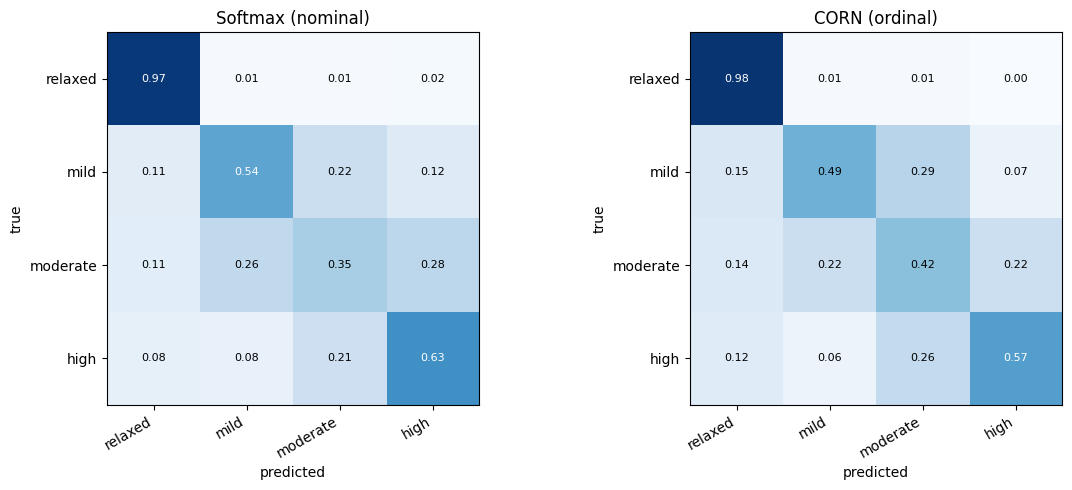

In [10]:
from sklearn.metrics import confusion_matrix
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,(yt,yp,title) in zip(axes,[(yt_soft,yp_soft,'Softmax (nominal)'),(yt_corn,yp_corn,'CORN (ordinal)')]):
    cm=confusion_matrix(yt,yp,labels=range(NCLS))
    cmn=cm/cm.sum(axis=1,keepdims=True)
    im=ax.imshow(cmn,cmap='Blues',vmin=0,vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CLASS_NAMES,rotation=30,ha='right'); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(title)
    for i in range(4):
        for j in range(4): ax.text(j,i,f"{cmn[i,j]:.2f}",ha='center',va='center',fontsize=8,
                                    color='white' if cmn[i,j]>0.5 else 'black')
plt.tight_layout(); plt.savefig(f'{SAVE}/ordinal_confusion.png',dpi=150); plt.show()

## 10. Save + Interpretation Guide

In [11]:
summary={'softmax':ms,'corn':mc,
         'perfold_f1':{'softmax':{str(s):soft_pf[s] for s in subs},'corn':{str(s):corn_pf[s] for s in subs}}}
with open(f'{SAVE}/ordinal_results.json','w') as f: json.dump(summary,f,indent=2,default=float)
print("Saved ordinal_results.json\n")
print("HOW TO REPORT (pick the matching case):")
print("-"*60)
print("A) CORN lowers MA-MAE and distant-error rate (even if F1 flat):")
print("   -> 'The ordinal formulation reduces error SEVERITY: distant")
print("      misclassifications and macro-MAE fall, confirming that")
print("      respecting the ordinal structure produces less harmful")
print("      errors, the property that matters for an ordinal target.'")
print("B) CORN improves F1 too: report as a clean win on both axes.")
print("C) CORN is flat/worse on all metrics:")
print("   -> 'The ordinal structure is confirmed by U3 but not")
print("      exploitable at n=15; softmax with quadratic-kappa")
print("      evaluation already captures most of the benefit.'")
print("   (Still a legitimate, honest, reportable finding.)")

Saved ordinal_results.json

HOW TO REPORT (pick the matching case):
------------------------------------------------------------
A) CORN lowers MA-MAE and distant-error rate (even if F1 flat):
   -> 'The ordinal formulation reduces error SEVERITY: distant
      misclassifications and macro-MAE fall, confirming that
      respecting the ordinal structure produces less harmful
      errors, the property that matters for an ordinal target.'
B) CORN improves F1 too: report as a clean win on both axes.
C) CORN is flat/worse on all metrics:
   -> 'The ordinal structure is confirmed by U3 but not
      exploitable at n=15; softmax with quadratic-kappa
      evaluation already captures most of the benefit.'
   (Still a legitimate, honest, reportable finding.)


## 11. Contribution Statement
Regardless of outcome, the contribution is:

> The first application of ordinal-regression deep learning (CORN) to multi-level
> wearable HRV stress inference, evaluated with ordinal-appropriate metrics
> (macro-averaged MAE, distant-error rate). Where prior work — including all surveyed
> WESAD multi-level studies — treats stress levels as unordered categories, this work
> tests whether explicitly modelling the ordering reduces the severity of errors, which
> is the property that matters when the predicted level drives a graded intervention.

Frame the result honestly around **error severity (MA-MAE, distant errors)**, not only
macro-F1, because that is the axis the ordinal formulation is designed to improve.